In [9]:
# Imports for plots and to read csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style('whitegrid')
sns.set_palette('deep')

# Stores csv data in python variable
nhts_data = pd.read_csv('NHTS(in).csv')
ngsim_data = pd.read_csv('NGSIM(in).csv')

<Figure size 2000x1000 with 0 Axes>

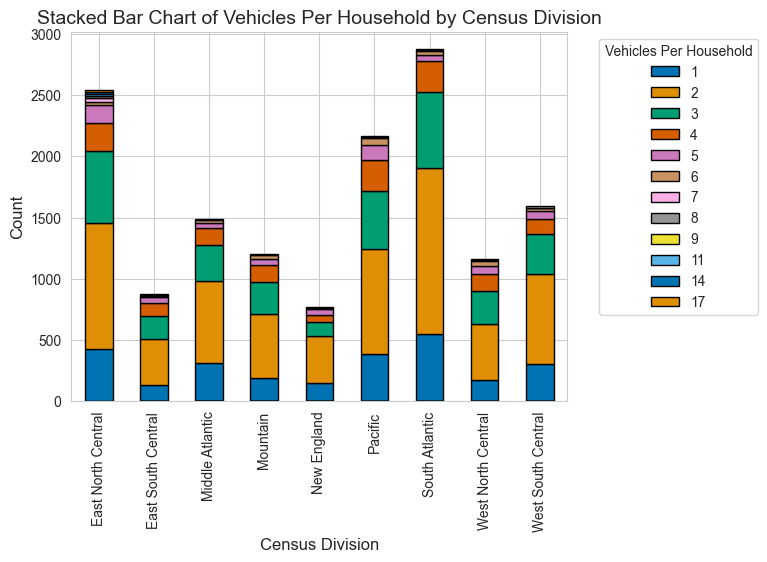

In [10]:
# Grouping and counting by 'census_division' and 'vehicles_per_household'
data_grouped = nhts_data.groupby(['census_division', 'vehicles_per_household']).size().unstack(fill_value=0)

# Plotting
plt.figure(figsize=(20,10))

# Plotting stacked bar chart
data_grouped.plot(kind='bar', edgecolor = 'black', stacked = True, color = sns.color_palette('colorblind', len(data_grouped.columns)))

# Customizing the plot
plt.legend(title = 'Vehicles Per Household', bbox_to_anchor = (1.05,1), loc = 'upper left')
plt.xlabel('Census Division', fontsize = 12)
plt.ylabel('Count', fontsize = 12)
plt.title('Stacked Bar Chart of Vehicles Per Household by Census Division', fontsize=14)

# Show the plot
plt.show()

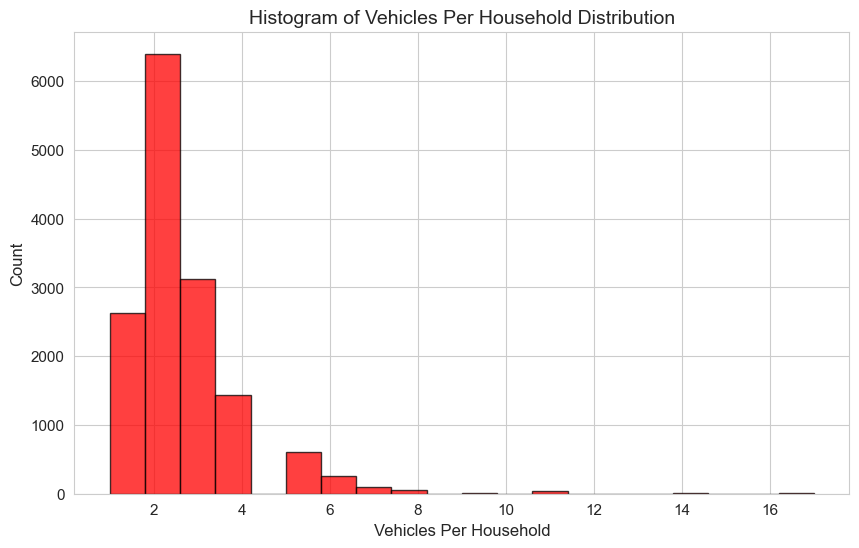

In [11]:
# Plotting
plt.figure(figsize = (10,6))

# Plotting histogram
plt.hist(nhts_data['vehicles_per_household'], bins = 20, color = 'red', edgecolor = 'black', alpha = .75)

# Customizing the plot
plt.xlabel('Vehicles Per Household', fontsize = 12)
plt.ylabel('Count', fontsize = 12)
plt.title('Histogram of Vehicles Per Household Distribution', fontsize=14)
plt.xticks(fontsize = 11)
plt.yticks(fontsize = 11)

# Show the plot
plt.show()

<Figure size 1400x800 with 0 Axes>

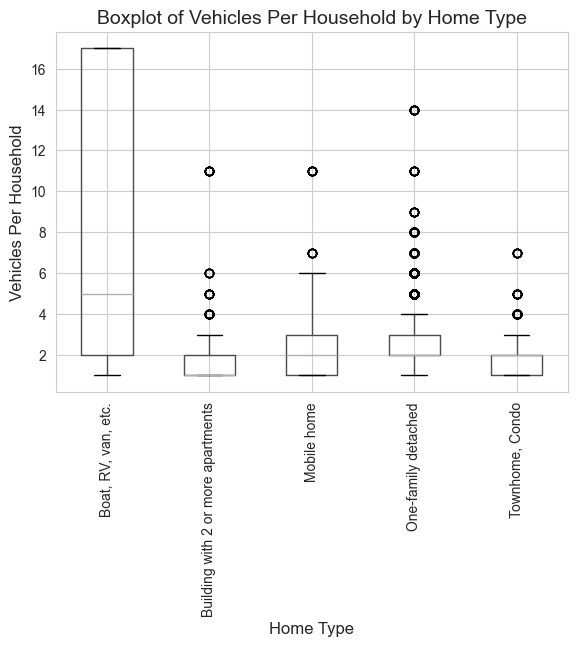

In [12]:
# Plotting
plt.figure(figsize = (14,8))

# Plotting boxplot
boxplot = nhts_data.boxplot(column = 'vehicles_per_household', by = 'home_type')

# Customizing the plot
plt.xticks(rotation=90)
plt.xlabel('Home Type', fontsize = 12)
plt.ylabel('Vehicles Per Household', fontsize = 12)
plt.title('Boxplot of Vehicles Per Household by Home Type', fontsize=14)
plt.suptitle('')

# Show the plot
plt.show()

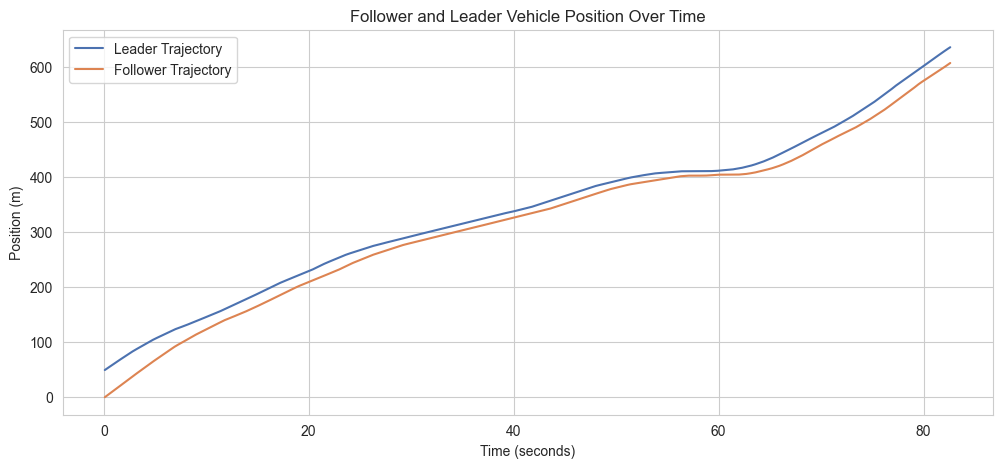

In [21]:
# Trajectory data selected
trajectory_number =  4

# Filter data based on trajectory
data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number].reset_index(drop = True)

# Plotting
plt.figure(figsize = (12,5))

# Plotting leader and follower trajectories on line plot
sns.lineplot(data = data_subset, x = 'Time', y = 'leader_position(m)', label = 'Leader Trajectory')
sns.lineplot(data = data_subset, x = 'Time', y = 'follower_position(m)', label = 'Follower Trajectory')

# Customizing the plot
plt.xlabel('Time (seconds)')
plt.ylabel('Position (m)')
plt.title('Follower and Leader Vehicle Position Over Time')

# Show the plot
plt.show()

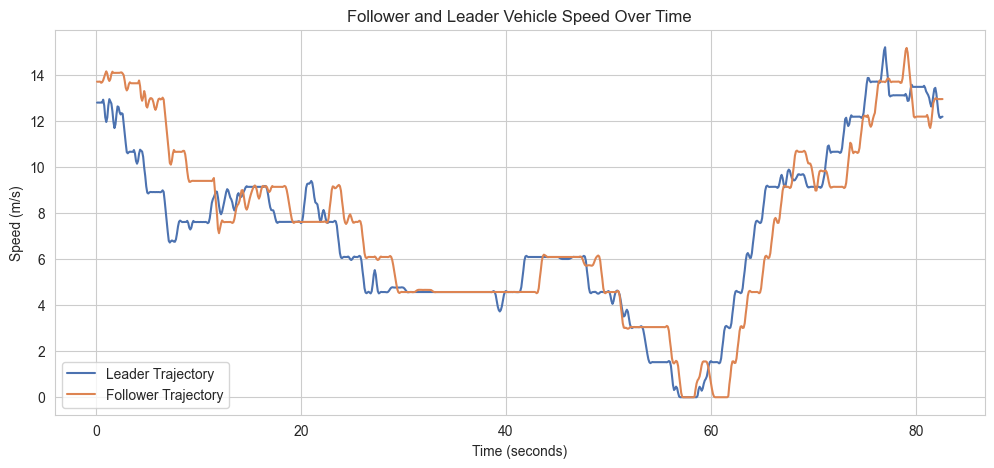

In [22]:
# Plotting
plt.figure(figsize = (12,5))

# Plotting leader and follower trajectories on line plot
sns.lineplot(data = data_subset, x = 'Time', y = 'leader_speed(m/s)', label = 'Leader Trajectory')
sns.lineplot(data = data_subset, x = 'Time', y = 'follower_speed(m/s)', label = 'Follower Trajectory')

# Customizing the plot
plt.xlabel('Time (seconds)')
plt.ylabel('Speed (m/s)')
plt.title('Follower and Leader Vehicle Speed Over Time')

# Show the plot
plt.show()

In [36]:
# Function to compute the IDM acceleration
def idm_acceleration(v, s, delta_v, v0, s0, T, a, b, delta):
    # Step 1: Calculate the desired minimum gap s_star
    s_star = s0 + v * T + (v * delta_v) / (2 * np.sqrt(a * b))
    
    # Make sure s_star is not negative
    s_star = max(s_star, s0)
    
    # Step 2: Calculate the acceleration using the IDM equation
    acceleration = a * (1 - (v/v0)**delta - (s_star/s)**2)
    
    return acceleration




# Extract the leader's position and speed over time
time_data = data_subset['Time'].values
leader_position = data_subset['leader_position(m)'].values
leader_speed = data_subset['leader_speed(m/s)'].values

# Identifying the time step in our data
dt = 0.1 # (s)



# Set the IDM parameters
v0 = 30    # desired velocity (m/s)
s0 = 2     # minimum spacing (m)
T = 1.5    # desired time headway (s)
a = 1.0    # maximum acceleration (m/s^2)  
b = 1.5    # comfortable deceleration (m/s^2)
delta = 4  # acceleration exponent

# Initialize arrays to store simulation results
n_steps = len(time_data)             # number of simulation steps we will take, which will be equal to the length of the trajectory data
sim_position = np.zeros(n_steps)         # simulated follower position; we will create a vector with all zeroes  as a start
sim_speed = np.zeros(n_steps)           # simulated follower speed; we will create a vector with all zeroes  as a start
sim_acc = np.zeros(n_steps)           # simulated follower acceleration; we will create a vector with all zeroes  as a start

# Start at the real follower's initial state
sim_position[0] = data_subset['follower_position(m)'].values[0]      # this makes the starting value [0] same as the follower vehicle position
sim_speed[0] = data_subset['follower_speed(m/s)'].values[0]        # this makes the starting value [0] same as the follower vehicle speed

In [30]:
# Loop to run simulation
for i in range(n_steps - 1):
    # Step 1 & 2: Calculate the gap and speed difference at this time step
    gap = max(leader_position[i] - sim_position[i], 0.1)
    delta_v = sim_speed[i] - leader_speed[i]
    
    # Step 3: Use the IDM function to calculate acceleration
    sim_acc[i] = idm_acceleration(sim_speed[i], gap, delta_v, v0, s0, T, a, b, delta)

    # Step 4 & 5: Update speed and position for the next time step
    sim_speed[i+1] = max(sim_speed[i] + sim_acc[i]* dt, 0)
    sim_position[i+1] = sim_position[i] + sim_speed[i] * dt

print("Simulation complete!")

Simulation complete!


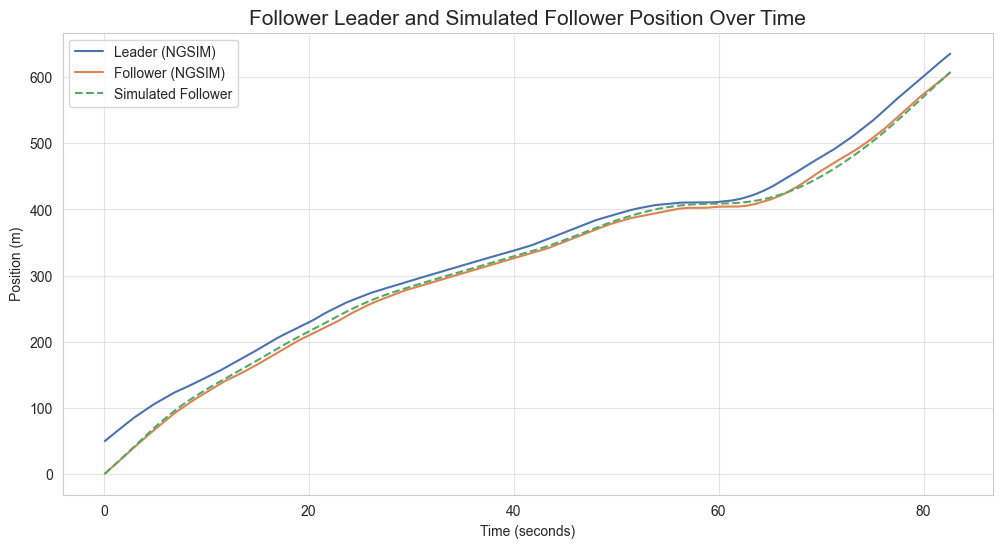

In [35]:
# Plotting
plt.figure(figsize = (12,6))

# Plotting leader, follower and simulated follower trajectories
plt.plot(time_data, leader_position, label = 'Leader (NGSIM)')
plt.plot(time_data, data_subset['follower_position(m)'].values, label = 'Follower (NGSIM)')
plt.plot(time_data, sim_position, label = 'Simulated Follower', linestyle='--')

# Customizing the plot
plt.title('Follower Leader and Simulated Follower Position Over Time', fontsize = 15)
plt.xlabel('Time (seconds)')
plt.ylabel('Position (m)')
plt.legend()
plt.grid(True, alpha = .5)

# Show the plot
plt.show()